In [1]:
import sys
import numpy as np
import pandas as pd
sys.path.append('../src')
from features import build_returns_matrix
from data_loader import VN30_TICKERS

# Build returns matrix 30 mã
matrix = build_returns_matrix(VN30_TICKERS, '2021-01-01', '2026-04-10')

# Tính Covariance Matrix — annualized
cov_matrix = matrix.cov() * 252

print("Shape:", cov_matrix.shape)
print("\nDiagonal (Variance của từng mã = Volatility²):")
for ticker in ['VCB', 'HPG', 'KDC', 'HVN']:
    var = cov_matrix.loc[ticker, ticker]
    vol = np.sqrt(var)
    print(f"  {ticker}: Var={var:.4f}, Volatility=√{var:.4f}={vol:.2%}")

print("\nSample — 5×5 góc trên trái:")
print(cov_matrix.iloc[:5, :5].round(4))

Shape: (30, 30)

Diagonal (Variance của từng mã = Volatility²):
  VCB: Var=0.0640, Volatility=√0.0640=25.29%
  HPG: Var=0.1145, Volatility=√0.1145=33.84%
  KDC: Var=0.0324, Volatility=√0.0324=18.00%
  HVN: Var=0.1777, Volatility=√0.1777=42.16%

Sample — 5×5 góc trên trái:
        VCB     BID     CTG     TCB     MBB
VCB  0.0640  0.0438  0.0419  0.0353  0.0383
BID  0.0438  0.1038  0.0719  0.0609  0.0643
CTG  0.0419  0.0719  0.1051  0.0706  0.0746
TCB  0.0353  0.0609  0.0706  0.1089  0.0787
MBB  0.0383  0.0643  0.0746  0.0787  0.0966


Correlation range:
  Min: 0.053
  Max: 0.767
  Mean: 0.360


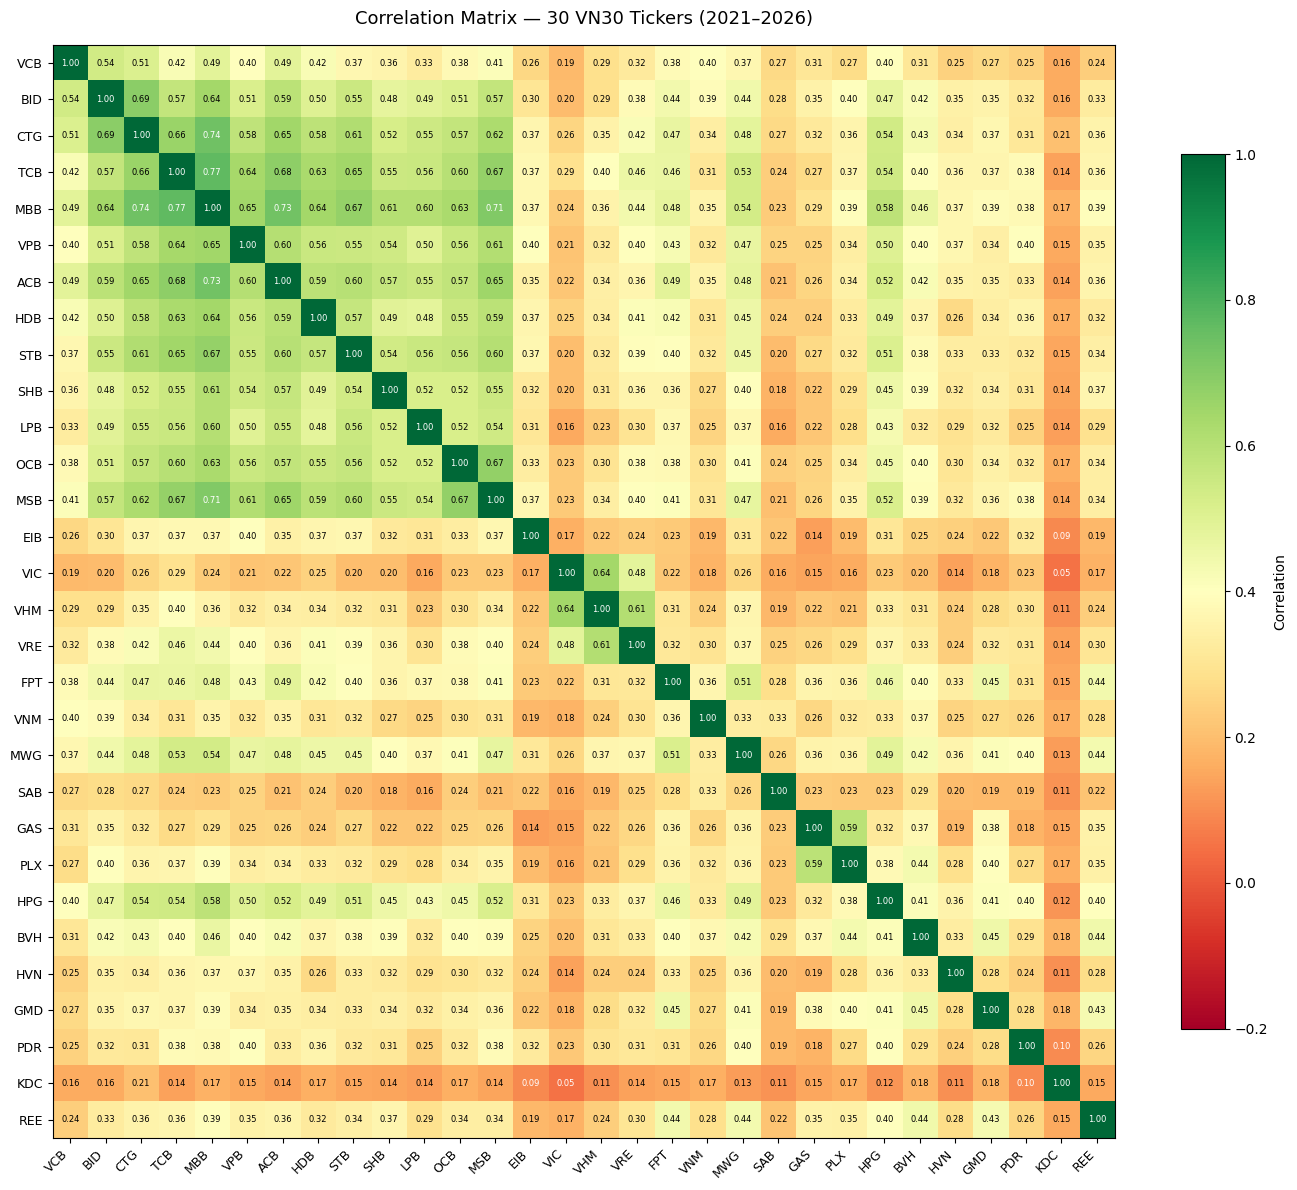

✅ Saved


In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Correlation Matrix
corr_matrix = matrix.corr()

print("Correlation range:")
print(f"  Min: {corr_matrix.values[corr_matrix.values < 1].min():.3f}")
print(f"  Max: {corr_matrix.values[corr_matrix.values < 1].max():.3f}")
print(f"  Mean: {corr_matrix.values[corr_matrix.values < 1].mean():.3f}")

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 12))

im = ax.imshow(corr_matrix.values, cmap='RdYlGn',
               vmin=-0.2, vmax=1.0, aspect='auto')

# Ticks
ax.set_xticks(range(len(VN30_TICKERS)))
ax.set_yticks(range(len(VN30_TICKERS)))
ax.set_xticklabels(VN30_TICKERS, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(VN30_TICKERS, fontsize=9)

# Giá trị trong ô
for i in range(len(VN30_TICKERS)):
    for j in range(len(VN30_TICKERS)):
        val = corr_matrix.values[i, j]
        color = 'white' if val > 0.7 or val < 0.1 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=6, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Correlation')
ax.set_title('Correlation Matrix — 30 VN30 Tickers (2021–2026)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved")

In [3]:
# Tìm cặp tương quan cao nhất và thấp nhất
import itertools

pairs = []
for i, j in itertools.combinations(range(len(VN30_TICKERS)), 2):
    t1, t2 = VN30_TICKERS[i], VN30_TICKERS[j]
    corr = corr_matrix.loc[t1, t2]
    pairs.append({'Ticker1': t1, 'Ticker2': t2, 'Correlation': round(corr, 3)})

df_pairs = pd.DataFrame(pairs).sort_values('Correlation', ascending=False)

print("=== TOP 10 cặp tương quan CAO nhất (diversification kém) ===")
print(df_pairs.head(10).to_string(index=False))

print("\n=== TOP 10 cặp tương quan THẤP nhất (diversification tốt) ===")
print(df_pairs.tail(10).to_string(index=False))

print("\n=== Tương quan trung bình theo nhóm ngành ===")
banks   = ['VCB','BID','CTG','TCB','MBB','VPB','ACB','HDB','STB','SHB','LPB','OCB','MSB','EIB']
others  = ['VIC','VHM','VRE','FPT','VNM','MWG','SAB','GAS','PLX','HPG','BVH','HVN','GMD','PDR','KDC','REE']

bank_corr  = corr_matrix.loc[banks, banks]
cross_corr = corr_matrix.loc[banks, others]

mask = np.ones(bank_corr.shape, dtype=bool)
np.fill_diagonal(mask, False)
print(f"Ngân hàng vs Ngân hàng : {bank_corr.values[mask].mean():.3f}")
print(f"Ngân hàng vs Ngành khác: {cross_corr.values.mean():.3f}")

=== TOP 10 cặp tương quan CAO nhất (diversification kém) ===
Ticker1 Ticker2  Correlation
    TCB     MBB        0.767
    CTG     MBB        0.740
    MBB     ACB        0.735
    MBB     MSB        0.706
    BID     CTG        0.689
    TCB     ACB        0.682
    OCB     MSB        0.674
    TCB     MSB        0.671
    MBB     STB        0.670
    CTG     TCB        0.660

=== TOP 10 cặp tương quan THẤP nhất (diversification tốt) ===
Ticker1 Ticker2  Correlation
    EIB     GAS        0.136
    LPB     KDC        0.135
    MWG     KDC        0.130
    HPG     KDC        0.115
    SAB     KDC        0.111
    VHM     KDC        0.107
    HVN     KDC        0.106
    PDR     KDC        0.100
    EIB     KDC        0.091
    VIC     KDC        0.053

=== Tương quan trung bình theo nhóm ngành ===
Ngân hàng vs Ngân hàng : 0.533
Ngân hàng vs Ngành khác: 0.326


In [4]:
import importlib
import portfolio_metrics
importlib.reload(portfolio_metrics)
from portfolio_metrics import (expected_returns, covariance_matrix,
                                portfolio_stats, display_metrics)

START = '2021-01-01'
END   = '2026-04-10'
N     = len(VN30_TICKERS)

# Tính inputs
mu  = expected_returns(VN30_TICKERS, START, END)
cov = covariance_matrix(VN30_TICKERS, START, END)

print("Expected returns — top 5 và bottom 5:")
print(mu.sort_values(ascending=False).head(5).apply(lambda x: f"{x:.2%}"))
print("...")
print(mu.sort_values(ascending=False).tail(5).apply(lambda x: f"{x:.2%}"))

print(f"\nCovariance Matrix shape: {cov.shape}")
print(f"Diagonal range (Variance): {np.diag(cov.values).min():.4f} – {np.diag(cov.values).max():.4f}")

Expected returns — top 5 và bottom 5:
LPB    50.40%
STB    35.48%
VIC    32.05%
HDB    30.81%
MBB    29.53%
dtype: str
...
PLX     5.93%
VRE     4.03%
VNM    -0.10%
PDR    -0.72%
SAB    -4.39%
dtype: str

Covariance Matrix shape: (30, 30)
Diagonal range (Variance): 0.0324 – 0.1828


In [6]:
import importlib
import portfolio_metrics
importlib.reload(portfolio_metrics)
from portfolio_metrics import (expected_returns, covariance_matrix,
                                portfolio_stats, display_metrics)
import numpy as np

START = '2021-01-01'
END   = '2026-04-10'

# ── Test 3 mã verify tay ──────────────────────────────────────
test_tickers = ['VCB', 'VNM', 'KDC']
mu3  = expected_returns(test_tickers, START, END)
cov3 = covariance_matrix(test_tickers, START, END)
w3   = np.array([1/3, 1/3, 1/3])

stats = portfolio_stats(w3, mu3, cov3)

print("=== Python output (VCB + VNM + KDC, equal weights) ===")
print(f"Return    : {stats['port_return']:.6f}  ({stats['port_return']:.2%})")
print(f"Volatility: {stats['port_volatility']:.6f}  ({stats['port_volatility']:.2%})")
print(f"Sharpe    : {stats['sharpe_ratio']:.6f}")
print(f"Variance  : {stats['port_variance']:.6f}")

# ── Tính tay verify ───────────────────────────────────────────
print("\n=== Tính tay verify ===")
r_manual = (mu3['VCB'] + mu3['VNM'] + mu3['KDC']) / 3
print(f"Return tay : {r_manual:.6f}  {'✅' if abs(r_manual - stats['port_return']) < 1e-8 else '❌'}")

var_manual = float(w3 @ cov3.values @ w3)
vol_manual = np.sqrt(var_manual)
print(f"Vol tay    : {vol_manual:.6f}  {'✅' if abs(vol_manual - stats['port_volatility']) < 1e-8 else '❌'}")

sharpe_manual = (r_manual - 0.045) / vol_manual
print(f"Sharpe tay : {sharpe_manual:.6f}  {'✅' if abs(sharpe_manual - stats['sharpe_ratio']) < 1e-8 else '❌'}")

# ── Equal weights 30 mã ───────────────────────────────────────
from data_loader import VN30_TICKERS
N  = len(VN30_TICKERS)
mu = expected_returns(VN30_TICKERS, START, END)
cov = covariance_matrix(VN30_TICKERS, START, END)

w_equal = np.array([1/N] * N)
display_metrics(VN30_TICKERS, w_equal, mu, cov,
                label='Equal Weights — 30 VN30 tickers')

=== Python output (VCB + VNM + KDC, equal weights) ===
Return    : 0.052925  (5.29%)
Volatility: 0.165024  (16.50%)
Sharpe    : 0.048024
Variance  : 0.027233

=== Tính tay verify ===
Return tay : 0.052925  ✅
Vol tay    : 0.165024  ✅
Sharpe tay : 0.048024  ✅

  Equal Weights — 30 VN30 tickers
  Expected Return    :   18.98%
  Volatility (Risk)  :   20.67%
  Sharpe Ratio       :    0.701
Ticker Weight Exp Return
   VCB   3.3%      11.0%
   BID   3.3%      17.3%
   CTG   3.3%      23.1%
   TCB   3.3%      20.1%
   MBB   3.3%      29.5%
   VPB   3.3%      25.3%
   ACB   3.3%      21.5%
   HDB   3.3%      30.8%
   STB   3.3%      35.5%
   SHB   3.3%      27.3%
   LPB   3.3%      50.4%
   OCB   3.3%      14.2%
   MSB   3.3%      19.2%
   EIB   3.3%      21.2%
   VIC   3.3%      32.0%
   VHM   3.3%      18.9%
   VRE   3.3%       4.0%
   FPT   3.3%      25.0%
   VNM   3.3%      -0.1%
   MWG   3.3%      20.0%
   SAB   3.3%      -4.4%
   GAS   3.3%      15.1%
   PLX   3.3%       5.9%
   HPG   3.

,Ticker,Weight,Exp Return
0,VCB,3.3%,11.0%
1,BID,3.3%,17.3%
2,CTG,3.3%,23.1%
3,TCB,3.3%,20.1%
4,MBB,3.3%,29.5%
5,VPB,3.3%,25.3%
6,ACB,3.3%,21.5%
7,HDB,3.3%,30.8%
8,STB,3.3%,35.5%
9,SHB,3.3%,27.3%
